# Stage 4: Data Cleaning & EDA
## Meridian Trust Bank — Personal Loan Application Credit Scorecard

**Business question:** Before we build anything, is this data trustworthy?
What does it actually look like? What relationships already jump out?

This notebook works from `modeling_dataset.csv` — the Python-side equivalent
of the `vw_modeling_dataset` SQL view (Script 04), i.e. the 5,578 applications
with a full 18-month performance window and a valid `bad_flag`.

**What a real Credit Risk Analyst does here, and why:**
- Confirms the data lines up with what SQL already validated (never trust a
  second copy of data blindly, even your own export).
- Looks for missingness patterns that might differ from what a raw null-count
  suggests (is missing "random," or does it cluster by segment — e.g. missing
  income concentrated among the self-employed?).
- Checks distributions for outliers or impossible values BEFORE they leak
  into WOE binning in Stage 5, where a single wild outlier can distort a bin's
  boundaries.
- Looks at bivariate relationships between candidate predictors and `bad_flag`
  — this is where you build genuine intuition for which variables might carry
  signal, well before running any formal IV calculation in Stage 6.

**Common mistake this stage exists to prevent:** jumping straight to WOE/IV
without ever looking at the raw distributions. IV will happily assign a
plausible-looking value to a variable with a data quality problem — it has no
way of knowing the "signal" it found is actually a broken pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

df = pd.read_csv('../01_data/raw_csv/modeling_dataset.csv', parse_dates=['application_date', 'date_of_birth', 'customer_since'])
print(df.shape)
df.head()

(5578, 30)


,application_id,customer_id,application_date,loan_purpose,loan_amount_requested,term_months,interest_rate_offered,channel,bad_flag,first_name,last_name,date_of_birth,age_at_2024,gender,state,postcode,employment_type,employment_tenure_months,annual_income,residential_status,dependents,customer_since,bureau_credit_score,enquiries_last_6m,active_credit_accounts,defaults_on_file,months_since_last_delinquency,total_existing_debt,credit_utilization_pct,credit_file_age_months
0,APP000002,CUST004185,2023-03-19,Home Renovation,21500,36,19.86,Broker,1,Mark,Walker,1997-04-16,26,M,SA,2997,Casual,19,51888.14,Living with Family,3,2016-10-17,490,4,5,2,11.0,40969.56,100.0,20
1,APP000005,CUST004903,2023-03-11,Medical,23500,48,14.92,Broker,0,James,Stone,1999-04-17,24,M,NT,2501,Full-Time,2,98983.50,Owner,0,2018-05-20,636,2,3,1,15.0,24384.48,50.8,41
2,APP000006,CUST003890,2023-08-19,Home Renovation,29500,24,18.28,Online,0,Michael,Osborne,1973-05-16,50,M,NSW,2634,Part-Time,5,36862.91,Mortgage,2,2020-04-05,675,2,4,0,NaN,17081.66,38.0,98
3,APP000009,CUST004673,2023-04-19,Home Renovation,23500,12,10.14,Online,0,Amy,King,1977-09-02,46,F,QLD,2912,Self-Employed,4,45813.93,Owner,4,2017-06-13,625,2,6,1,31.0,14937.50,70.5,140
4,APP000010,CUST001316,2023-09-07,Home Renovation,29000,36,12.92,Online,0,Christopher,Miller,1986-08-22,37,M,QLD,2619,Self-Employed,32,80016.09,Owner,0,2019-03-20,783,1,4,0,NaN,0.00,35.7,175


## 4.1 — Shape and grain check

**Predict before you run:** how many rows and columns do you expect? We know
from Script 04 in SQL: 5,578 rows (the modeling population after excluding
indeterminates), and a wide set of columns from four joined source tables.

Run the cell below and confirm it matches your SQL output. If it doesn't,
STOP — don't proceed with two disagreeing datasets.

In [2]:
print("Rows:", df.shape[0], "| Columns:", df.shape[1])
print("\nExpected from SQL (vw_modeling_dataset): 5,578 rows")
print("Overall bad rate:", round(df['bad_flag'].mean(), 4), "| Expected: ~0.0348")

# grain check: application_id should be unique here (1 row per application)
print("\nDuplicate application_ids:", df['application_id'].duplicated().sum())

Rows: 5578 | Columns: 30

Expected from SQL (vw_modeling_dataset): 5,578 rows
Overall bad rate: 0.0348 | Expected: ~0.0348

Duplicate application_ids: 0


## 4.2 — Missing value audit

**Expected finding:** `months_since_last_delinquency` should be missing
exactly where `defaults_on_file == 0` — this was already validated in SQL
(Script 03, check C2). Let's confirm it holds in this Python copy too, and
look at everything else.

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'n_missing': missing, 'pct_missing': missing_pct})
missing_summary = missing_summary[missing_summary['n_missing'] > 0].sort_values('pct_missing', ascending=False)
missing_summary

,n_missing,pct_missing
months_since_last_delinquency,4859,87.11


In [4]:
# Confirm the expected null pattern: months_since_last_delinquency missing
# ONLY when defaults_on_file == 0
inconsistent = df[
    ((df['defaults_on_file'] == 0) & (df['months_since_last_delinquency'].notna())) |
    ((df['defaults_on_file'] > 0) & (df['months_since_last_delinquency'].isna()))
]
print("Inconsistent rows:", len(inconsistent))
print("(Expected: 0 — this null pattern is EXPECTED and MEANINGFUL, not a data quality problem.")
print(" It tells us 'no prior delinquency' rather than 'unknown.' We'll handle this explicitly")
print(" as a SPECIAL CATEGORY in WOE binning (Stage 5), not by imputing a numeric value that")
print(" would misrepresent 'never delinquent' as some specific number of months.)")

Inconsistent rows: 0
(Expected: 0 — this null pattern is EXPECTED and MEANINGFUL, not a data quality problem.
 It tells us 'no prior delinquency' rather than 'unknown.' We'll handle this explicitly
 as a SPECIAL CATEGORY in WOE binning (Stage 5), not by imputing a numeric value that
 would misrepresent 'never delinquent' as some specific number of months.)


## 4.3 — Range / sanity checks

Re-running the same logic as SQL Script 03 Section D, on this Python copy.
This is deliberately redundant with SQL — that's the point. Two independent
checks on two independent copies of the data catch different classes of bugs
(a SQL-side bug in the BULK INSERT step vs. a Python-side bug in a join).

In [5]:
checks = {
    'age_at_2024': (df['age_at_2024'].min(), df['age_at_2024'].max(), '18-75 expected'),
    'annual_income': (df['annual_income'].min(), df['annual_income'].max(), '> 0'),
    'bureau_credit_score': (df['bureau_credit_score'].min(), df['bureau_credit_score'].max(), '300-900 (AU bureau range)'),
    'loan_amount_requested': (df['loan_amount_requested'].min(), df['loan_amount_requested'].max(), '2,000-50,000 expected'),
    'credit_utilization_pct': (df['credit_utilization_pct'].min(), df['credit_utilization_pct'].max(), '0-100 expected'),
    'employment_tenure_months': (df['employment_tenure_months'].min(), df['employment_tenure_months'].max(), '>= 0'),
}
for col, (mn, mx, expected) in checks.items():
    print(f"{col:30s} min={mn:>12} max={mx:>12}   ({expected})")

age_at_2024                    min=          18 max=          74   (18-75 expected)
annual_income                  min=     15000.0 max=   157787.78   (> 0)
bureau_credit_score            min=         380 max=         900   (300-900 (AU bureau range))
loan_amount_requested          min=        2000 max=       50000   (2,000-50,000 expected)
credit_utilization_pct         min=         0.0 max=       100.0   (0-100 expected)
employment_tenure_months       min=           0 max=         296   (>= 0)


## 4.4 — Duplicate check

We already confirmed `application_id` is unique (the grain). But could the
same underlying application have been entered twice under different IDs? A
crude proxy: same customer, same loan amount, same application date.

In [6]:
dupe_candidates = df.duplicated(subset=['customer_id', 'loan_amount_requested', 'application_date'], keep=False)
print("Suspicious duplicate candidates:", dupe_candidates.sum())
# Expected: 0 or very low, since these are independently generated synthetic applications.
# In a REAL dataset, this check catches things like a customer accidentally
# submitting the same application twice through a broken web form.

Suspicious duplicate candidates: 0


## 4.5 — Univariate distributions: numeric variables

Look at the shape of each numeric variable BEFORE any binning decision. What
you're looking for:
- Skew (does it need a log transform, or will WOE binning handle it naturally?)
- Outliers (a handful of extreme values that could distort bin edges)
- Multi-modality (does the distribution have distinct clusters — e.g. a
  spike at 0 for `employment_tenure_months` from the Unemployed segment?)

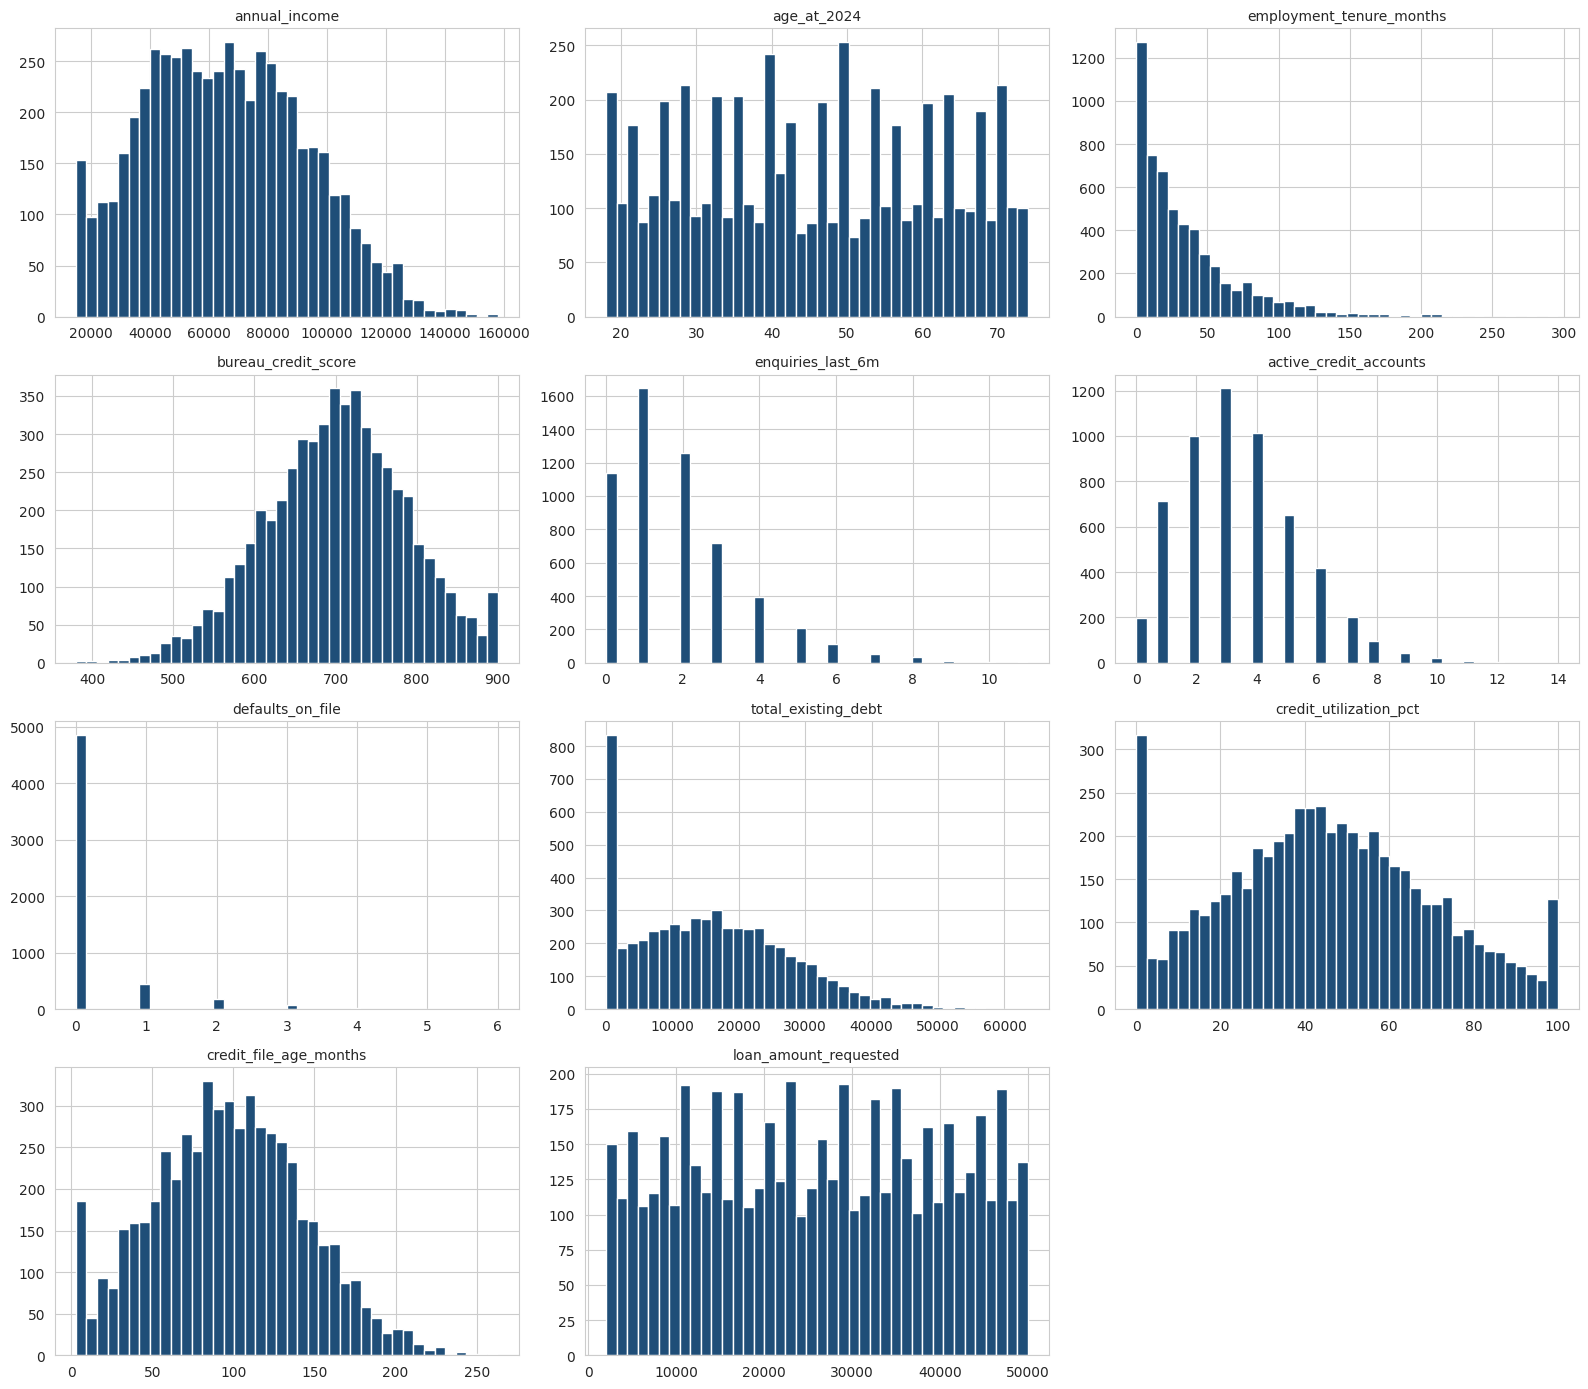

In [7]:
numeric_cols = ['annual_income', 'age_at_2024', 'employment_tenure_months',
                'bureau_credit_score', 'enquiries_last_6m', 'active_credit_accounts',
                'defaults_on_file', 'total_existing_debt', 'credit_utilization_pct',
                'credit_file_age_months', 'loan_amount_requested']

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='#1F4E78', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

**What to notice:**
- `employment_tenure_months` should show a spike at 0 (the Unemployed
  segment) plus a right-skewed distribution for everyone else.
- `defaults_on_file` should be heavily concentrated at 0, with a long thin
  tail — this is typical for bureau default counts.
- `bureau_credit_score` should look roughly bell-shaped but slightly
  left-skewed (long tail toward low scores) — bureau scores are usually
  constructed this way deliberately, to spread out the risky tail where
  decisions matter most.

**A genuine limitation of synthetic data, worth naming explicitly:** because
we generated these distributions from parametric formulas (normal, Poisson,
exponential), they'll look "cleaner" than real bureau data, which usually has
lumpiness from system quirks, rounding conventions, and historical policy
changes (e.g. a spike of accounts all opened on the same day due to a
portfolio acquisition). Don't over-index on how clean these look — real data
exploration usually turns up more mess than this.

## 4.6 — Categorical variable distributions

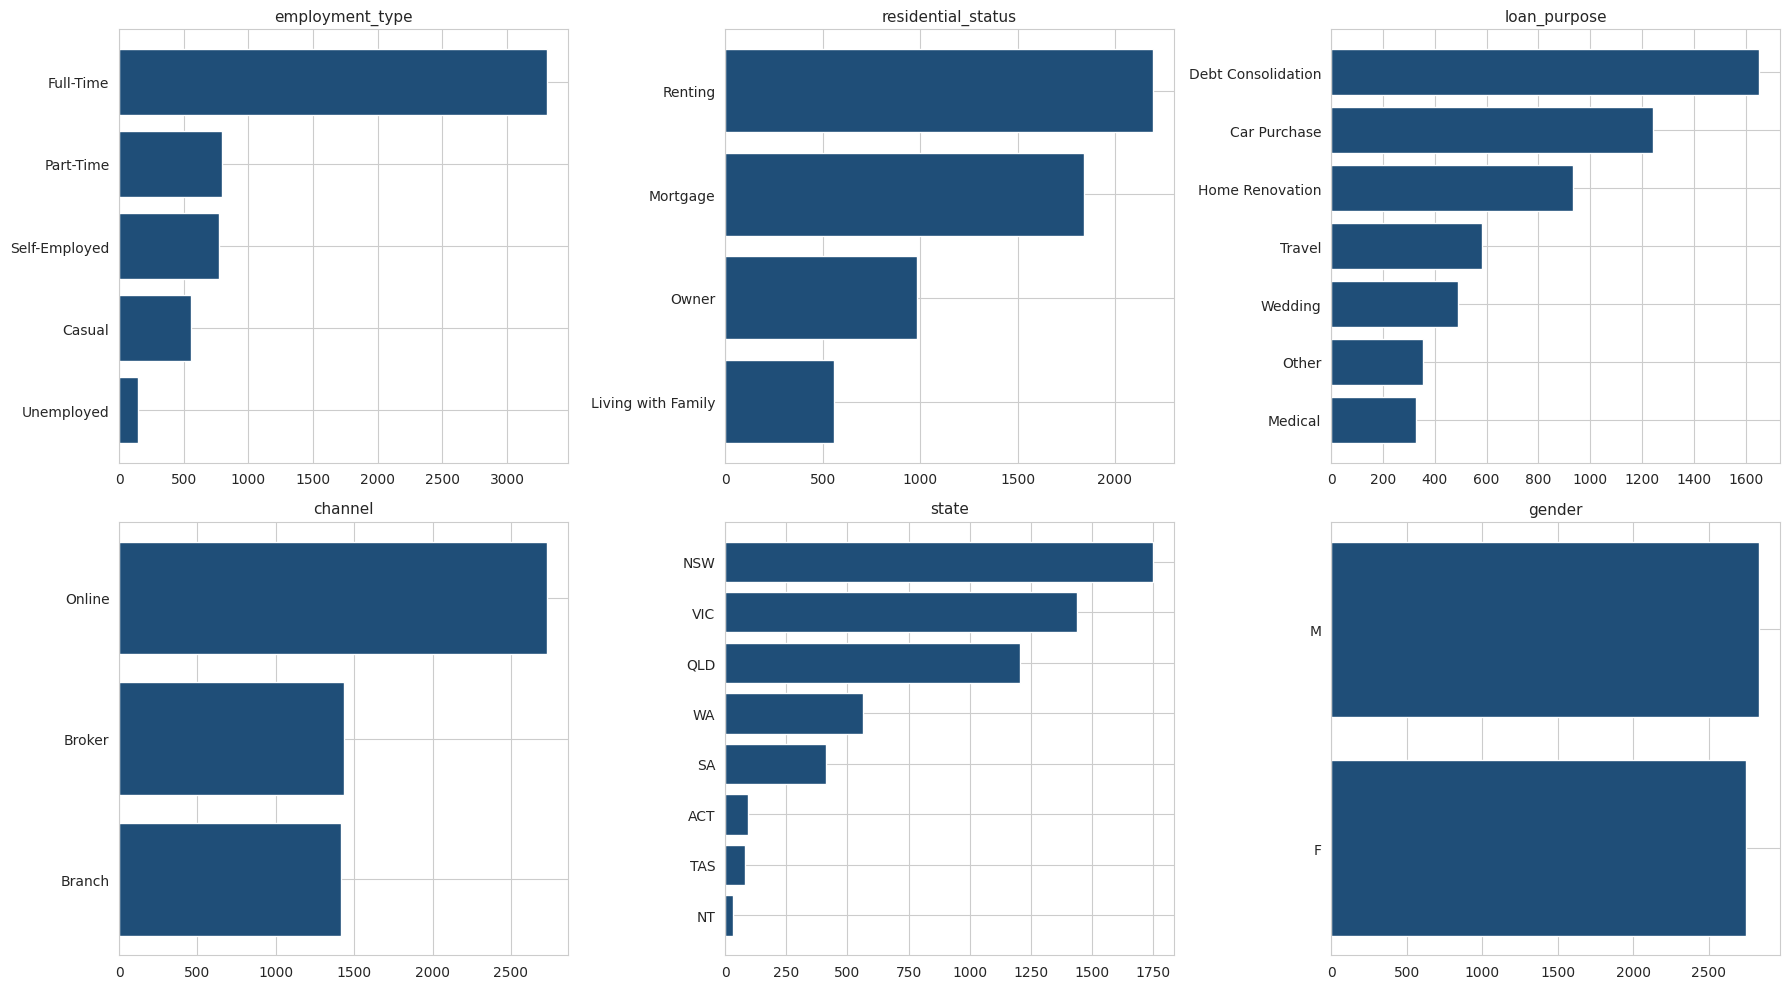

In [8]:
cat_cols = ['employment_type', 'residential_status', 'loan_purpose', 'channel', 'state', 'gender']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].barh(counts.index, counts.values, color='#1F4E78')
    axes[i].set_title(col, fontsize=11)
    axes[i].invert_yaxis()
plt.tight_layout()
plt.show()

## 4.7 — Bivariate: bad rate by segment

This is the heart of exploratory work for a scorecard project — not just
"what does the distribution look like" but "does this variable actually
separate Good from Bad?" This is informal, visual groundwork for the formal
WOE/IV analysis coming in Stage 5-6.

**Predict before you run:** based on domain knowledge, which of these
categorical variables do you expect to show the STRONGEST bad-rate
separation? (Hint: think about which ones are plausible causal or
correlated drivers of repayment capacity vs. which are closer to
noise/demographic labels.)

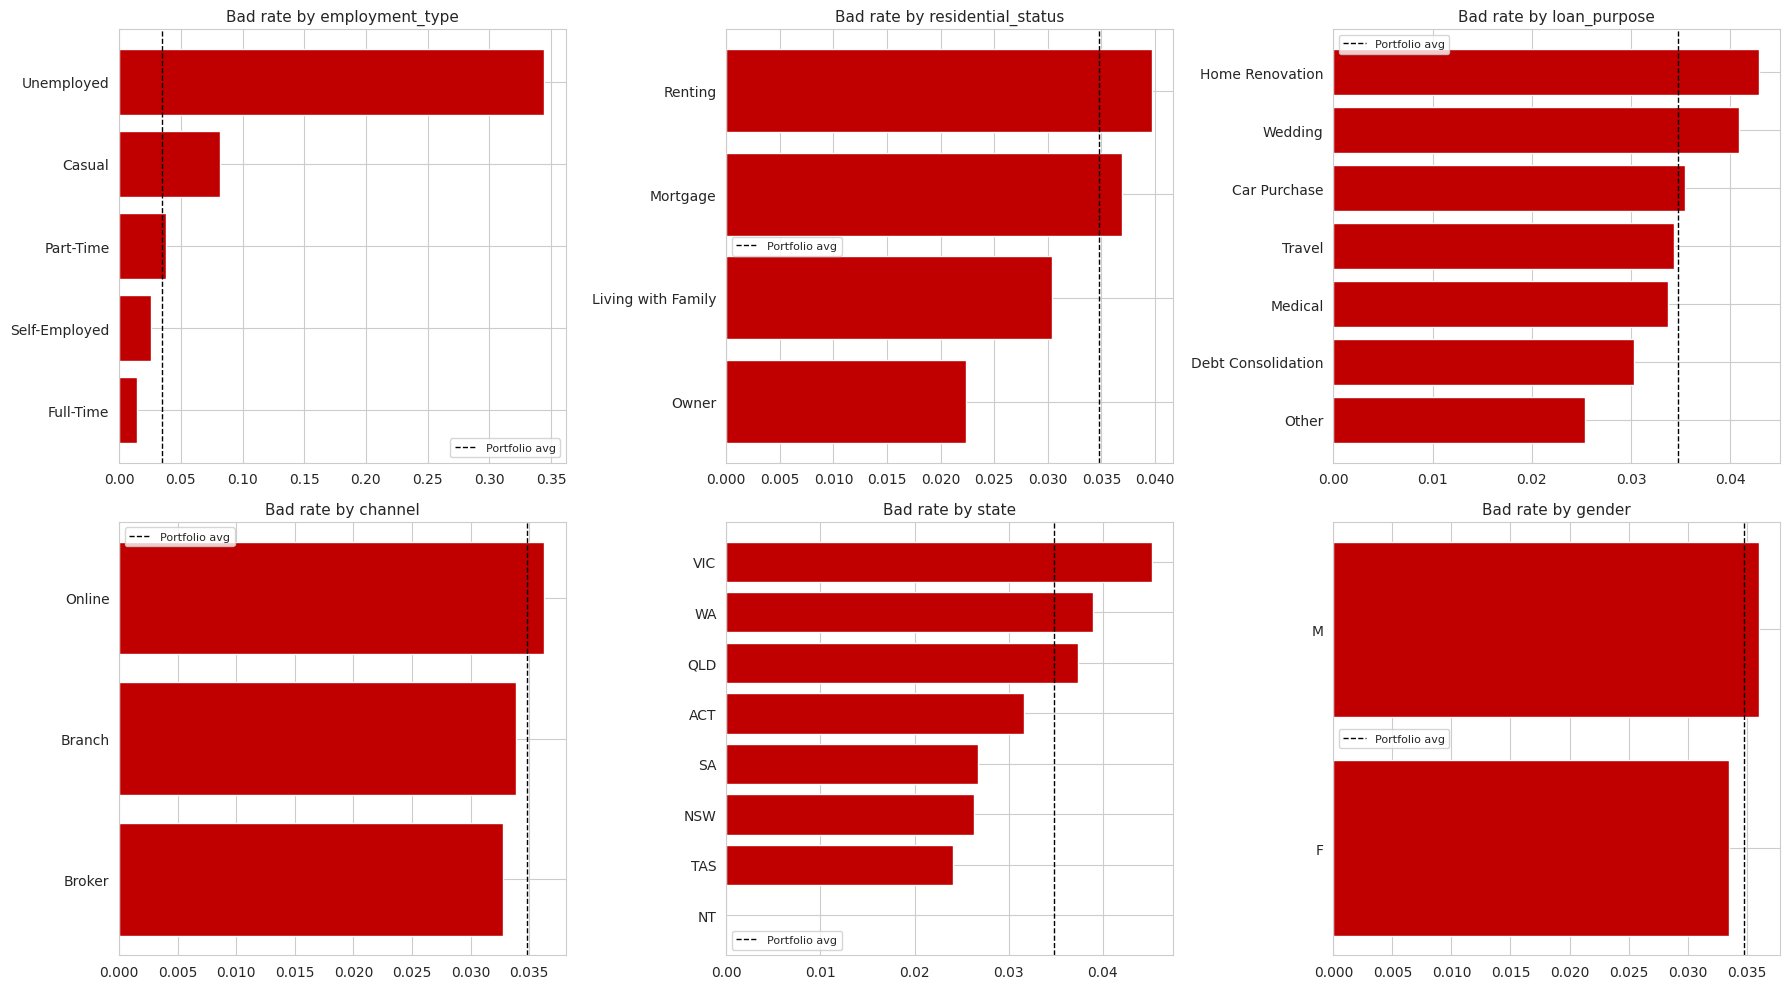

Portfolio average bad rate: 0.0348


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    rates = df.groupby(col)['bad_flag'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    axes[i].barh(rates.index, rates['mean'], color='#C00000')
    axes[i].set_title(f"Bad rate by {col}", fontsize=11)
    axes[i].axvline(df['bad_flag'].mean(), color='black', linestyle='--', linewidth=1, label='Portfolio avg')
    axes[i].legend(fontsize=8)
    axes[i].invert_yaxis()
plt.tight_layout()
plt.show()

print("Portfolio average bad rate:", round(df['bad_flag'].mean(), 4))

**What you should see:**
- `employment_type`: Unemployed and Casual should show materially higher bad
  rates than Full-Time — this is a real driver baked into how the data was
  generated (repayment capacity genuinely differs by employment stability).
- `residential_status`, `loan_purpose`, `channel`, `state`, `gender`: expect
  these to show much WEAKER separation — some may look almost flat against
  the portfolio average. This is intentional and realistic: not every
  variable in a real dataset is predictive, and knowing which ones AREN'T is
  just as important as finding the ones that are (this is exactly what
  Stage 6's IV calculation will quantify formally).

**Common mistake:** treating every variable in the dataset as a candidate
predictor without first checking whether it shows ANY separation. WOE/IV
will run on `postcode` just as happily as on `bureau_credit_score` — it has
no opinion about which one is a sensible business driver. That judgment is
yours, and it starts here, with a simple bar chart.

## 4.8 — Bivariate: bad rate by numeric variable (binned into deciles)

For numeric variables, we bin into deciles just for this exploratory pass
(Stage 5 will do this properly and deliberately as coarse/fine classing —
this is a quick look, not the final binning).

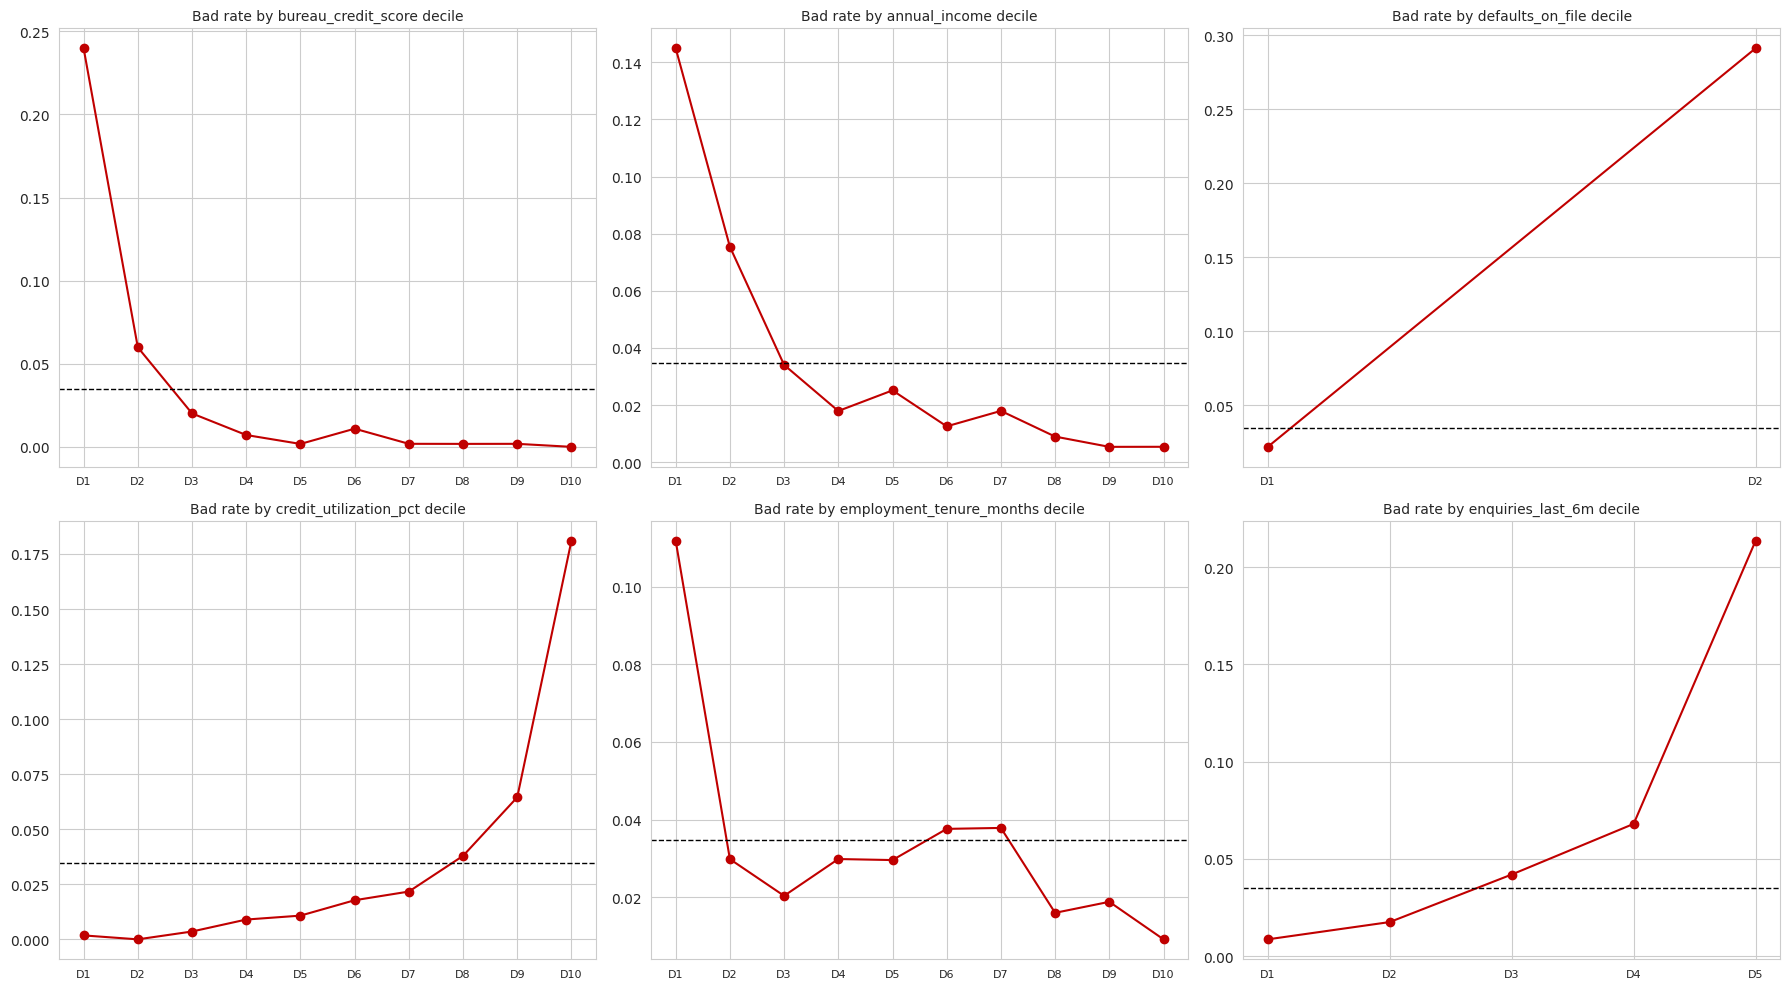

In [10]:
numeric_check_cols = ['bureau_credit_score', 'annual_income', 'defaults_on_file',
                      'credit_utilization_pct', 'employment_tenure_months', 'enquiries_last_6m']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_check_cols):
    try:
        df['_decile'] = pd.qcut(df[col], 10, duplicates='drop')
    except ValueError:
        df['_decile'] = pd.cut(df[col], 10)
    rates = df.groupby('_decile', observed=True)['bad_flag'].mean()
    axes[i].plot(range(len(rates)), rates.values, marker='o', color='#C00000')
    axes[i].set_title(f"Bad rate by {col} decile", fontsize=10)
    axes[i].axhline(df['bad_flag'].mean(), color='black', linestyle='--', linewidth=1)
    axes[i].set_xticks(range(len(rates)))
    axes[i].set_xticklabels([f"D{j+1}" for j in range(len(rates))], fontsize=8)
df = df.drop(columns=['_decile'])
plt.tight_layout()
plt.show()

**What to notice:** `bureau_credit_score` and `defaults_on_file` should
show strong, close-to-monotonic relationships with bad rate — exactly what
you want a scorecard variable to look like (this is a preview of "good WOE
behavior" before we formalize it in Stage 5). Weaker variables will look
noisy or flat.

**A note on how clean this looks:** because our latent risk factor was
deliberately constructed to drive both bureau attributes AND the default
outcome, these relationships are cleaner and more monotonic than you'd
typically see in real bureau data, where noise, sampling variation, and
genuine non-linearities (e.g. a "sweet spot" utilization level) are more
common. Treat this dataset as a strong teaching example of what "good
scorecard variable behavior" looks like — not as a realistic expectation for
how clean your first real-world EDA will be.

## 4.9 — Correlation among numeric variables

Before we get to modeling, it's worth checking correlation structure —
multicollinearity between candidate predictors will matter a lot once we
build a logistic regression in Stage 7 (correlated variables inflate standard
errors and make coefficients hard to interpret).

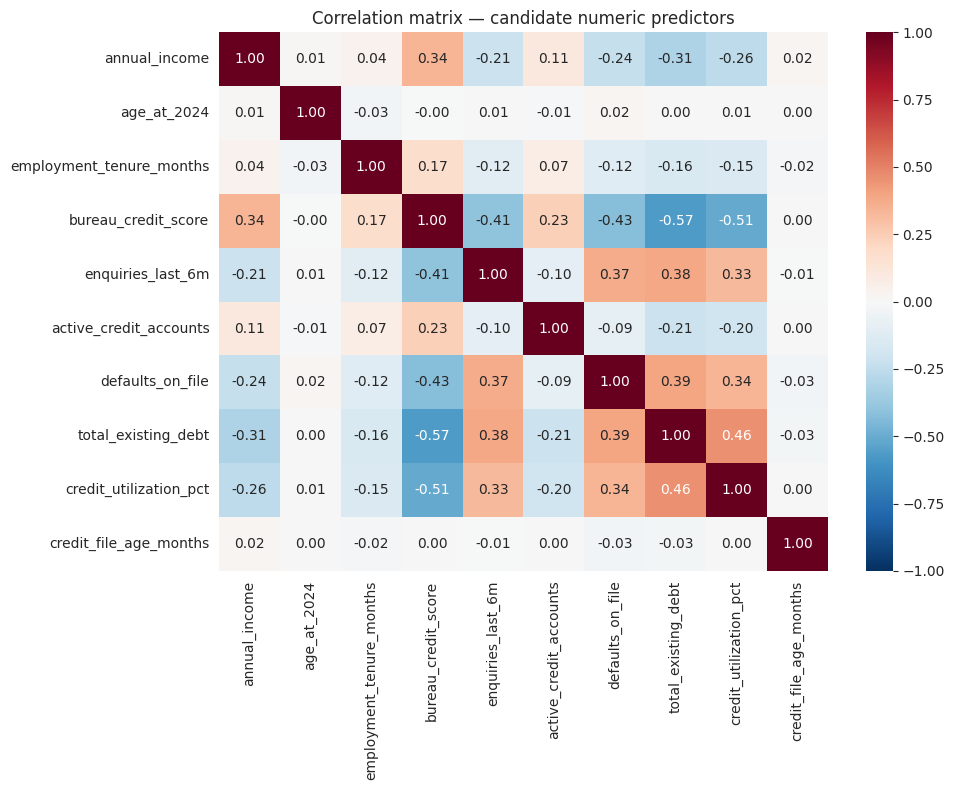

In [11]:
corr_cols = ['annual_income', 'age_at_2024', 'employment_tenure_months',
             'bureau_credit_score', 'enquiries_last_6m', 'active_credit_accounts',
             'defaults_on_file', 'total_existing_debt', 'credit_utilization_pct',
             'credit_file_age_months']

corr = df[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Correlation matrix — candidate numeric predictors')
plt.tight_layout()
plt.show()

**What to look for:** any pair above ~0.6-0.7 absolute correlation is
worth flagging now, even though WOE transformation (Stage 5) will somewhat
change these relationships. `total_existing_debt` and `credit_utilization_pct`
are plausible candidates for correlation, since both relate to existing debt
burden — worth watching in Stage 7's coefficient stability.

## 4.10 — Checkpoint: what would you flag before moving to WOE binning?

Before Stage 5, a real analyst would write up a short EDA summary memo. Some
prompts to work through yourself (this is where the "teach through the
project" instruction matters most — write your own answers before reading
mine):

1. Which 3-4 variables look like the strongest scorecard candidates based on
   what you've seen so far, and why?
2. Which variables look weak or flat, and would you drop them now, or wait
   for the formal IV calculation in Stage 6 to confirm?
3. `months_since_last_delinquency` is missing for ~85%+ of applications
   (everyone with `defaults_on_file = 0`). How would you handle this in WOE
   binning — impute a value, or treat missingness as its OWN category?
   (Hint: think about what a missing value here actually MEANS from a
   business perspective — is it "unknown," or is it informative in itself?)
4. `interest_rate_offered` exists in the raw applications table but was
   deliberately NOT included in `modeling_dataset.csv`. Why would including
   it as a model feature be a data leakage risk, even though it's technically
   known "at application time"? (Hint: what determines the interest rate
   offered, and in what order does that happen relative to the underwriting
   decision this model is meant to support?)

**My answer to Q4** (since this one is a genuine common mistake, worth
stating directly rather than leaving as an exercise): `interest_rate_offered`
is typically set AFTER a risk assessment — i.e. it's priced off some version
of the applicant's risk, whether from this same scorecard's predecessor or a
manual underwriting judgment. Using it as an input to predict `bad_flag`
means using an output of a risk decision to predict an outcome of that same
risk — the model would partly learn to reverse-engineer the OLD scorecard
rather than independently assess risk from raw applicant characteristics.
This is a subtle but very real, very common data leakage trap in credit risk
modeling — always ask "what determined this value, and did that determination
process already use information about risk?" before including a field.